# CanSat Apogee Detection — XGBoost Training

Compiles every `*_metrics.csv` in `video input/csv output/` into one pandas
DataFrame, derives a binary apogee target from the `phase` column, and trains an
XGBoost classifier.

- **y = apogee**: `1` when `phase == 'APOGEE'`, else `0`
- **Features**: all 69 numeric columns, excluding the identity/label columns
  (`time_s`, `state`, `phase`, `src`)
- **Split**: per-video — whole videos are held out for test so the model is
  scored on unseen flights (random row splits leak same-video context)
- **Imbalance**: APOGEE is ~0.15% of frames, so `scale_pos_weight` is set from
  the train split and PR-AUC / ROC-AUC are reported


In [1]:
import glob
import os

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)

In [2]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess

    REPO = "AeroNottsCanSat-Landing-Detect"
    DATA_DIR = f"/content/{REPO}/video input/csv output"
    if not os.path.isdir(DATA_DIR):
        print("Colab: cloning repo to fetch training CSVs ...")
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/7-wwh/AeroNottsCanSat-Landing-Detect.git"],
            cwd="/content", check=True,
        )
    os.chdir(f"/content/{REPO}")
    print("Colab: working in", os.getcwd())

## 1. Load & compile all CSVs

Reads every `*_metrics.csv` under `video input/csv output/`, tags each row with
its source video via a `src` column, and concatenates into one dataset with a
fresh integer index covering all CSVs.

In [3]:
CSV_GLOB = "video input/csv output/*_metrics.csv"

paths = sorted(glob.glob(CSV_GLOB))
print(f"found {len(paths)} CSV files")

df = pd.concat(
    [pd.read_csv(p).assign(src=os.path.basename(p)) for p in paths],
    ignore_index=True,
)

print(f"compiled rows: {len(df):,}")
print(f"apogee frames: {(df['phase'] == 'APOGEE').sum()}")
df.head()

found 18 CSV files


compiled rows: 77,372
apogee frames: 117


,time_s,state,phase,radial_expansion,radial_expansion_median,radial_std,radial_p95,outward_frac,inward_frac,pt_displacement_mean,...,grad_magnitude_mean,sharpness,sky_fraction,ground_fraction,horizon_angle,horizon_pos,horizon_conf,expansion_rate,expansion_acceleration,src
0,0.0000,STABLE,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.9788,144.5587,0.3778,0.5892,-25.0037,0.3861,0.8754,0.0033,-0.0688,11_metrics.csv
1,0.0334,STABLE,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,41.9788,144.5587,0.3362,0.5642,-25.0037,0.3861,0.8754,0.0010,-0.0648,11_metrics.csv
2,0.0667,STABLE,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,41.9788,144.5587,0.3354,0.5618,-25.0037,0.3861,0.8754,-0.0010,-0.0567,11_metrics.csv
3,0.1001,STABLE,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,41.9788,144.5587,0.3354,0.5618,-25.0037,0.3861,0.8754,-0.0027,-0.0486,11_metrics.csv
4,0.1335,STABLE,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,41.9788,144.5587,0.3354,0.5619,-25.0037,0.3861,0.8754,-0.0042,-0.0405,11_metrics.csv


## 2. Build features X and target y

`y` is `1` where `phase == 'APOGEE'`. The label/identity columns (`time_s`,
`state`, `phase`, `src`) are dropped from the feature matrix.

Notes:
- `state` and `phase` are the labels themselves — never features.
- `hom_ok` is a 0-1 confidence score despite the name; it stays numeric.
- Horizon columns have many `nan`s; XGBoost handles missing values natively, so
  no imputation is applied.

In [4]:
y = (df['phase'] == 'APOGEE').astype(int)
X = df.drop(columns=['time_s', 'state', 'phase', 'src'])

print(f"feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"target positives: {y.sum()} / {len(y):,} ({100 * y.mean():.4f}%)")

feature matrix: 77,372 rows x 69 columns
target positives: 117 / 77,372 (0.1512%)


## 3. Per-video train/test split

Splits on `src` so whole videos go to either train or test. ~25% of videos are
held out. Rows are then assigned by their source video.

In [5]:
train_srcs, test_srcs = train_test_split(
    df['src'].unique(), test_size=0.25, random_state=42
)

train_mask = df['src'].isin(train_srcs)
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"train: {len(train_srcs)} videos, {X_train.shape[0]:,} rows, "
      f"{y_train.sum()} apogee")
print(f"test:  {len(test_srcs)} videos, {X_test.shape[0]:,} rows, "
      f"{y_test.sum()} apogee")
print("held-out videos:", sorted(test_srcs))

train: 13 videos, 55,539 rows, 85 apogee
test:  5 videos, 21,833 rows, 32 apogee
held-out videos: ['11_metrics.csv', '15_metrics.csv', '22_metrics.csv', '27_metrics.csv', '34_metrics.csv']


## 4. Train XGBoost

- `scale_pos_weight` = negatives / positives (computed from **train** only)
- `eval_metric='aucpr'` — precision-recall area suits the extreme imbalance
- early stopping on a validation split carved out of the training videos


In [6]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

X_tr, X_va, y_tr, y_va = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
)
model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
print(f"best iteration: {model.best_iteration}")

scale_pos_weight = 652.4


best iteration: 243


## 5. Evaluate on held-out videos

ROC-AUC: 0.6100
PR-AUC:  0.0025

              precision    recall  f1-score   support

           0      0.999     1.000     0.999     21801
           1      0.000     0.000     0.000        32

    accuracy                          0.998     21833
   macro avg      0.499     0.500     0.500     21833
weighted avg      0.997     0.998     0.998     21833



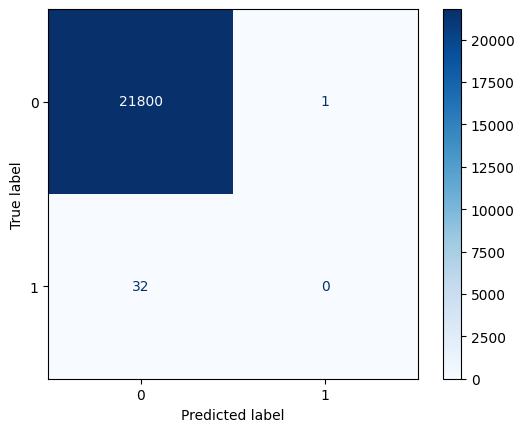

In [7]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues");

### Feature importance

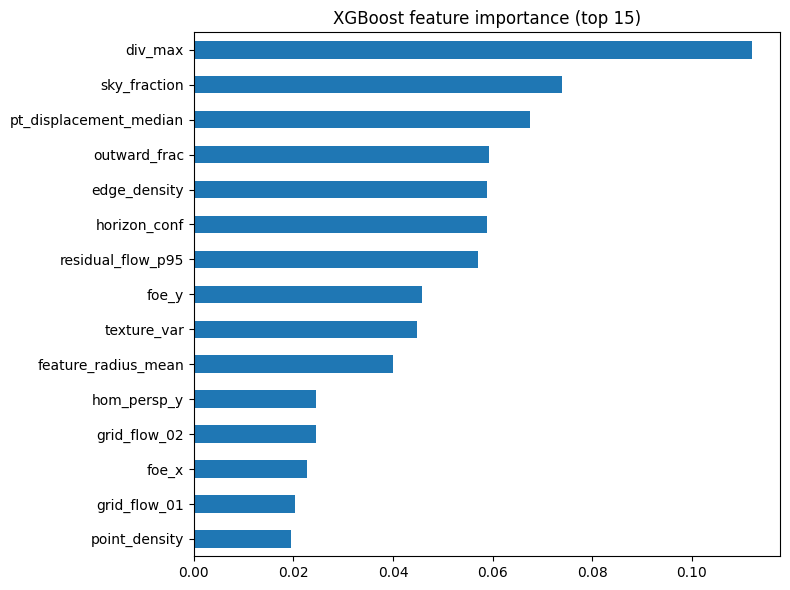

In [8]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.head(15).plot.barh(figsize=(8, 6))
plt.title("XGBoost feature importance (top 15)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Save the model

Saved with XGBoost's native `save_model` (UBJSON) as `flight_model.xgb` in the
repo root, matching the README's model naming. Reloadable with
`xgb.XGBClassifier().load_model('flight_model.xgb')`.

In Colab, run the final cell to download the trained model to your machine.


In [9]:
model.save_model('flight_model.xgb')
print("saved flight_model.xgb")

check = xgb.XGBClassifier()
check.load_model('flight_model.xgb')
print(f"reload OK — {check.predict(X_test).shape[0]:,} predictions")

saved flight_model.xgb
reload OK — 21,833 predictions


/home/ubuntu/.local/lib/python3.10/site-packages/xgboost/sklearn.py:1116: UserWarning: [14:22:53] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
/home/ubuntu/.local/lib/python3.10/site-packages/xgboost/sklearn.py:1125: UserWarning: [14:22:53] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


In [10]:
if IN_COLAB:
    from google.colab import files

    files.download("flight_model.xgb")
    print("flight_model.xgb downloaded - check your browser downloads folder")